In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import time
from src.kernels import green2d
from src.quadrature.integrands import integrand

In this notebook we compare a few quadrature methods to compute integrals of the form
$$ 
G(x, z, \omega) = \frac{1}{2 \pi} \int_{-\infty}^{+\infty} R(k_x, \omega) \, \frac{e^{i k_z |z|} e^{i k_x x}}{2 \imath k_z} \, dk_x, \quad k_z = \sqrt{k_0^2 - k_x^2}, \; k_0 = \omega / v_p,
$$
over a frequency range $\omega$, where $v_p$ is the P-wave velocity from the top layer containing the source/receiver pairs.  
We immediately see that the integral is singular when $k_x = k_0$.  
If we take $R(k_x, \omega) = 1$, we recover the 2D Green kernel $G(x, z, \omega) = \frac{i}{4} H_0^{(1)} (kr), \, r=\sqrt{x^2+z^2}$.


In [2]:
# set R=1 to do some testing
@nb.njit(fastmath=True)
def R(theta):
    return np.ones_like(theta)

# report max error over a frequency range
def err_metrics(cal, ref):
    #denom = np.maximum(np.abs(ref), 1e-12)
    err_max = np.max(np.abs(cal - ref)) #/ denom)
    err_l2 = np.linalg.norm(cal - ref) / np.linalg.norm(ref)
    print(f"max error {err_max:.3f}, L2 rel error {err_l2:.3f}")
    return err_max, err_l2

A first thing to do is to plot the integral within some bounds $[-k_{\text{max}}, k_{\text{max}}]$, for some fixed $\omega$.

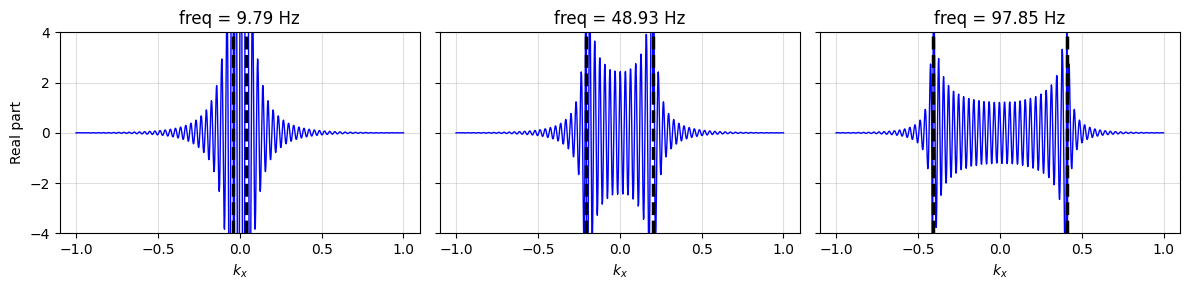

In [3]:
# define physical parametrization
freqs = np.linspace(0.01, 100.0, 512)
omega = 2.0 * np.pi * freqs
vp, dx, dz = 1500., 200., 5.
k0 = omega / vp
Green = green2d(omega, vp, np.sqrt(dx**2 + dz**2)) 

# plot the integrand over [k_min, k_max]
k_min, k_max = -1., 1.
k_range = np.linspace(k_min, k_max, 1000)
idxs = [50, 250, 500]
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, i in zip(axes, idxs):
    integran = integrand(k_range, k0[i], dz, dx, R)
    ax.plot(k_range, np.real(integran), 'b-', linewidth=1.)
    ax.axvline(k0[i], color='k', linestyle='--', linewidth=2.5)
    ax.axvline(-k0[i], color='k', linestyle='--', linewidth=2.5)
    ax.set_title(f"freq = {freqs[i]:.2f} Hz")
    ax.set_ylim([-4, 4])
    ax.grid(alpha=0.4)
    ax.set_xlabel(r'$k_x$')
axes[0].set_ylabel('Real part')
plt.tight_layout()
plt.show()

This looks terrific ! Let's try to use some standard rules : trapezoidal and Gauss-Legendre

In [4]:
from src.quadrature.gauss_leg import gauss_legendre_quad
from src.quadrature.trapezoidal import trapezoidal_quad
from src.utilities import timer
#from src.quadrature.integrands import integrand_prop, integrand

G_gauss = np.zeros(len(omega), dtype=complex)
nq = 1000  # number of quadrature points
with timer('GL quadrature'):
    G_gauss = gauss_legendre_quad(k_min, k_max, nq, k0[None, :], dz, dx, R, integrand)
G_gauss *= 1./(2.*np.pi)
max_err_gl = err_metrics(G_gauss, Green)

G_trap = np.zeros(len(omega), dtype=complex)
nq = 1000  # number of quadrature points
with timer('Trapezoidal quadrature'):
    G_trap = trapezoidal_quad(k_min, k_max, nq, k0[None, :], dz, dx, R, integrand)
G_trap *= 1./(2.*np.pi)
max_err_trapz = err_metrics(G_trap, Green)

GL quadrature elapsed: 0.27 s
max error 0.603, L2 rel error 0.994
Trapezoidal quadrature elapsed: 0.05 s
max error 0.483, L2 rel error 0.674


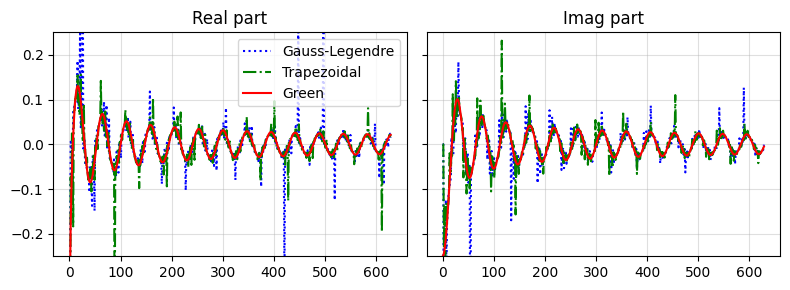

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
# --- Real part ---
axes[0].plot(omega, np.real(G_gauss.flatten()), 'b:', label='Gauss-Legendre')
axes[0].plot(omega, np.real(G_trap.flatten()), 'g-.', label='Trapezoidal')
axes[0].plot(omega, np.real(Green.flatten()), 'r', linewidth=1.5, label='Green')
axes[0].set_title("Real part")
axes[0].grid(alpha=0.4)
axes[0].set_ylim([-0.25, 0.25])
axes[0].legend()
# --- Imaginary part ---
axes[1].plot(omega, np.imag(G_gauss.flatten()), 'b:')
axes[1].plot(omega, np.imag(G_trap.flatten()), 'g-.')
axes[1].plot(omega, np.imag(Green.flatten()), 'r', linewidth=1.5)
axes[1].set_title("Imag part")
axes[1].set_ylim([-0.25, 0.25])
axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

The result is not very satisfying, and it highlights two key difficulties in this integral:
1. A singularity at $k_x = k_0$ : the integrand diverges, which standard quadrature methods do not handle well.
2. Strong oscillations when $k_0 r$ is large : the integrand varies rapidly, requiring too many points to resolve accurately at a reasonable cost

These two effects together make the Sommerfeld integral particularly challenging to evaluate numerically. Classical methods (like Gauss or trapezoidal rules) are not well adapted to this situation.

We will look at two ideas to target these difficulties : 
1. Deform the integration path into the complex plane
2. Split the integral into two regions
   - $k_x < k_0$, where the integrand is smooth and decaying
   - $k_x > k_0$, where the integrand is highly oscillatory
  
Then, treat each part with a specific quadrature method